# Notebook 2: Implementacja modeli

## Klasyfikacja sentymentu recenzji filmowych IMDB

W tym notebooku implementujemy dwa podejścia:

1. **Podejście klasyczne:** TF-IDF + SVM z GridSearchCV
2. **Podejście Transformer:** Fine-tuning `bert-base-uncased` (Hugging Face Trainer API)

Dane pochodzą z Notebooka 1 (`train.csv`, `val.csv`, `test.csv`).

> **Uwaga:** Część B wymaga GPU.  
> Google Colab: *Środowisko wykonawcze → Zmień tryb środowiska wykonawczego → T4 GPU*

## 1. Instalacja i importy

In [7]:
!pip install transformers datasets torch scikit-learn pandas matplotlib seaborn accelerate evaluate -q

In [8]:
import inspect
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, f1_score, precision_score, recall_score,
)

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (10, 6)
SEED = 42
print('Wszystko gotowe!')

Wszystko gotowe!


## 2. Wczytanie danych

In [6]:
from google.colab import drive
drive.mount('/content/drive')

# Ścieżka do folderu z danymi z Notebooku 1
DATA_PATH = '/content/drive/MyDrive/imdb/'

# Wczytanie danych przygotowanych w Notebooku 1
train_df = pd.read_csv(DATA_PATH + 'train.csv')
val_df = pd.read_csv(DATA_PATH + 'val.csv')
test_df = pd.read_csv(DATA_PATH + 'test.csv')

# Nazwy kolumn
TEXT_COL = 'text'       # surowy tekst dla BERT
CLEAN_COL = 'text_clean' # przetworzony tekst dla TF-IDF
LABEL_COL = 'sentiment'  # negative / positive

print(f'Train: {len(train_df):,}')
print(f'Val: {len(val_df):,}')
print(f'Test: {len(test_df):,}')
print(f'\nKolumny: {list(train_df.columns)}')
print(f'\nRozkład klas (train):')
print(train_df[LABEL_COL].value_counts())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Train: 7,000
Val: 1,500
Test: 1,500

Kolumny: ['text', 'text_clean', 'sentiment']

Rozkład klas (train):
sentiment
positive    3500
negative    3500
Name: count, dtype: int64


---
## CZĘŚĆ A: TF-IDF + SVM

Implementujemy pipeline TF-IDF → SVM z GridSearchCV



In [9]:
# Dane tekstowe dla TF-IDF
X_train = train_df[CLEAN_COL].fillna('').values
X_val = val_df[CLEAN_COL].fillna('').values
X_test = test_df[CLEAN_COL].fillna('').values

# Etykiety
y_train = train_df[LABEL_COL].values
y_val = val_df[LABEL_COL].values
y_test = test_df[LABEL_COL].values

print(f'X_train: {X_train.shape} | y_train: {y_train.shape}')
print(f'X_val: {X_val.shape}   | y_val: {y_val.shape}')
print(f'X_test: {X_test.shape}  | y_test: {y_test.shape}')

X_train: (7000,) | y_train: (7000,)
X_val: (1500,)   | y_val: (1500,)
X_test: (1500,)  | y_test: (1500,)


In [10]:
# Wektoryzacja TF-IDF wspólna dla wszystkich klasyfikatorów
tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1, 2), min_df=2, sublinear_tf=True)
X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)

print(f'Wymiary macierzy TF-IDF (train): {X_train_tfidf.shape}')

Wymiary macierzy TF-IDF (train): (7000, 20000)


In [11]:
# Trening trzech klasyfikatorów klasycznych
lr = LogisticRegression(max_iter=1000, random_state=SEED, class_weight='balanced')
nb = MultinomialNB()
svm = LinearSVC(max_iter=5000, random_state=SEED)

lr.fit(X_train_tfidf, y_train)
nb.fit(X_train_tfidf, y_train)
svm.fit(X_train_tfidf, y_train)

y_pred_lr  = lr.predict(X_val_tfidf)
y_pred_nb  = nb.predict(X_val_tfidf)
y_pred_svm = svm.predict(X_val_tfidf)

print('Trening zakończony.')

Trening zakończony.


In [12]:
# Tabela porównawcza wyników na zbiorze walidacyjnym
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Naive Bayes', 'SVM'],
    'Accuracy': [accuracy_score(y_val, y_pred_lr),
                  accuracy_score(y_val, y_pred_nb),
                 accuracy_score(y_val, y_pred_svm)],
    'F1': [f1_score(y_val, y_pred_lr,  average='weighted'),
          f1_score(y_val, y_pred_nb,  average='weighted'),
          f1_score(y_val, y_pred_svm, average='weighted')],
}).sort_values('F1', ascending=False).reset_index(drop=True)

print(comparison.round(4).to_string(index=False))

best_name = comparison.iloc[0]['Model']
print(f'\nNajlepszy model klasyczny: {best_name}')

              Model  Accuracy     F1
                SVM    0.8640 0.8640
Logistic Regression    0.8627 0.8626
        Naive Bayes    0.8553 0.8553

Najlepszy model klasyczny: SVM


In [13]:
# GridSearchCV na SVM  dobór hiperparametrów
pipeline_grid = Pipeline([
    ('tfidf', TfidfVectorizer(min_df=2, sublinear_tf=True)),
    # CalibratedClassifierCV dodaje predict_proba do LinearSVC
    ('clf',   CalibratedClassifierCV(LinearSVC(max_iter=5000, random_state=SEED))),
])

# Siatka parametrów
param_grid = {
    'tfidf__max_features': [10000, 20000],  # liczba cech
    'tfidf__ngram_range': [(1, 1), (1, 2)],  # unigramy vs bigramy
    'clf__estimator__C': [0.1, 1.0, 10.0],  # regularyzacja
}

grid_search = GridSearchCV(
    pipeline_grid, param_grid,
    cv=3, scoring='f1_weighted', n_jobs=-1, verbose=1
)
grid_search.fit(X_train, y_train)

print(f'\nNajlepsze parametry: {grid_search.best_params_}')
print(f'Najlepszy F1 (CV): {grid_search.best_score_:.4f}')

Fitting 3 folds for each of 12 candidates, totalling 36 fits

Najlepsze parametry: {'clf__estimator__C': 1.0, 'tfidf__max_features': 20000, 'tfidf__ngram_range': (1, 2)}
Najlepszy F1 (CV): 0.8630


In [14]:
# Ewaluacja modelu SVM na zbiorze testowym
best_classic = grid_search.best_estimator_
y_test_pred_classic = best_classic.predict(X_test)

classic_test_acc  = accuracy_score(y_test, y_test_pred_classic)
classic_test_prec = precision_score(y_test, y_test_pred_classic, average='weighted')
classic_test_rec  = recall_score(y_test, y_test_pred_classic, average='weighted')
classic_test_f1   = f1_score(y_test, y_test_pred_classic, average='weighted')

print('=== Wyniki SVM na zbiorze testowym ===')
print(f'Accuracy: {classic_test_acc:.4f}')
print(f'Precision: {classic_test_prec:.4f}')
print(f'Recall: {classic_test_rec:.4f}')
print(f'F1: {classic_test_f1:.4f}')
print(f'\nRaport klasyfikacji:')
print(classification_report(y_test, y_test_pred_classic))

=== Wyniki SVM na zbiorze testowym ===
Accuracy: 0.8627
Precision: 0.8627
Recall: 0.8627
F1: 0.8627

Raport klasyfikacji:
              precision    recall  f1-score   support

    negative       0.86      0.86      0.86       750
    positive       0.86      0.86      0.86       750

    accuracy                           0.86      1500
   macro avg       0.86      0.86      0.86      1500
weighted avg       0.86      0.86      0.86      1500



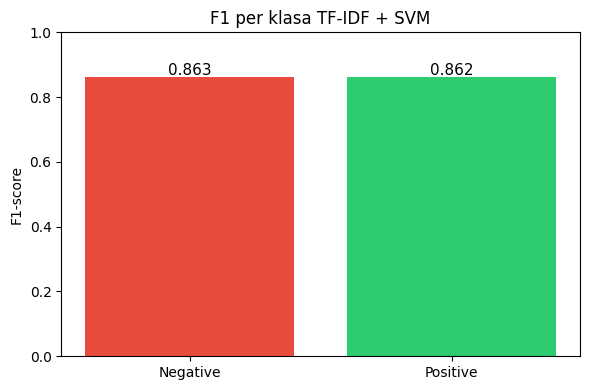

In [15]:
# F1 per klasa dla SVM
report = classification_report(y_test, y_test_pred_classic,
                                target_names=['Negative', 'Positive'],
                                output_dict=True)
classes = ['Negative', 'Positive']
f1_scores = [report[c]['f1-score'] for c in classes]

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(classes, f1_scores, color=['#e74c3c', '#2ecc71'])
for i, v in enumerate(f1_scores):
    ax.text(i, v + 0.005, f'{v:.3f}', ha='center', fontsize=11)
ax.set_ylim(0, 1)
ax.set_ylabel('F1-score')
ax.set_title('F1 per klasa TF-IDF + SVM')
plt.tight_layout()
plt.savefig('f1_per_class_classic.png', dpi=150)
plt.show()

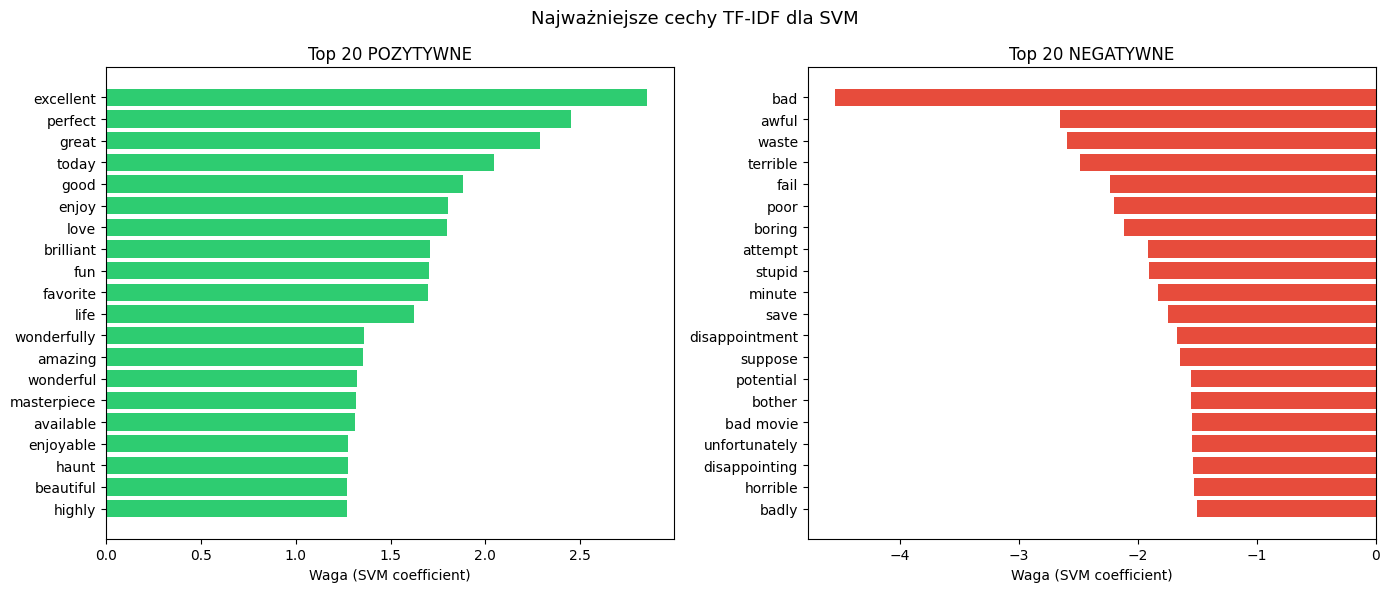

In [16]:
# Wykres najważniejszych cech interpretowalność SVM
feature_names = best_classic.named_steps['tfidf'].get_feature_names_out()
coefs = best_classic.named_steps['clf'].calibrated_classifiers_[0].estimator.coef_[0]
n_top = 20

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(feature_names[coefs.argsort()[-n_top:][::-1]],
             coefs[coefs.argsort()[-n_top:][::-1]], color='#2ecc71')
axes[0].set_title(f'Top {n_top} POZYTYWNE')
axes[0].set_xlabel('Waga (SVM coefficient)')
axes[0].invert_yaxis()

axes[1].barh(feature_names[coefs.argsort()[:n_top]],
             coefs[coefs.argsort()[:n_top]], color='#e74c3c')
axes[1].set_title(f'Top {n_top} NEGATYWNE')
axes[1].set_xlabel('Waga (SVM coefficient)')
axes[1].invert_yaxis()

plt.suptitle('Najważniejsze cechy TF-IDF dla SVM', fontsize=13)
plt.tight_layout()
plt.savefig('classic_feature_importance.png', dpi=150)
plt.show()

In [17]:
# Zapis wyników modelu klasycznego do JSON
classic_results = {
    'model': 'TF-IDF + SVM',
    'params': grid_search.best_params_,
    'accuracy': round(classic_test_acc, 4),
    'precision': round(classic_test_prec, 4),
    'recall': round(classic_test_rec, 4),
    'f1': round(classic_test_f1, 4),
}

with open('results_classic.json', 'w', encoding='utf-8') as f:
    json.dump(classic_results, f, ensure_ascii=False, indent=2)

print('Zapisano: results_classic.json')
print(classic_results)

Zapisano: results_classic.json
{'model': 'TF-IDF + SVM', 'params': {'clf__estimator__C': 1.0, 'tfidf__max_features': 20000, 'tfidf__ngram_range': (1, 2)}, 'accuracy': 0.8627, 'precision': 0.8627, 'recall': 0.8627, 'f1': 0.8627}


---
## CZĘŚĆ B: Fine-tuning bert-base-uncased

Fine-tuning modelu [`bert-base-uncased`](https://huggingface.co/bert-base-uncased) — anglojęzycznego BERT-a (110M parametrów).


> Uruchom na GPU: *Środowisko wykonawcze → Zmień tryb środowiska wykonawczego → T4 GPU*

In [18]:
import torch
from datasets import Dataset
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, DataCollatorWithPadding,
)
# Sprawdzenie dostępności GPU
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Urządzenie: {device}')
if device == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Urządzenie: cuda
GPU: Tesla T4


In [19]:
# Mapowanie etykiet tekstowych na liczby całkowite
LABEL2ID = {'negative': 0, 'positive': 1}
ID2LABEL  = {0: 'negative', 1: 'positive'}

for df in [train_df, val_df, test_df]:
    df['labels'] = df[LABEL_COL].map(LABEL2ID)

print('Mapowanie:', LABEL2ID)
print(train_df[['sentiment', 'labels']].head(3))

Mapowanie: {'negative': 0, 'positive': 1}
  sentiment  labels
0  positive       1
1  negative       0
2  negative       0


In [20]:
# Załadowanie tokenizatora BERT
MODEL_NAME = 'bert-base-uncased'
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print(f'Model: {MODEL_NAME}')
print(f'Rozmiar słownika: {tokenizer.vocab_size:,}')
print(f'Specjalne tokeny: CLS={tokenizer.cls_token}, SEP={tokenizer.sep_token}')

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Model: bert-base-uncased
Rozmiar słownika: 30,522
Specjalne tokeny: CLS=[CLS], SEP=[SEP]


Token indices sequence length is longer than the specified maximum sequence length for this model (874 > 512). Running this sequence through the model will result in indexing errors


Mediana: 222 tokenów
P75: 398 tokenów
P90: 615 tokenów
Maksimum: 1403 tokenów


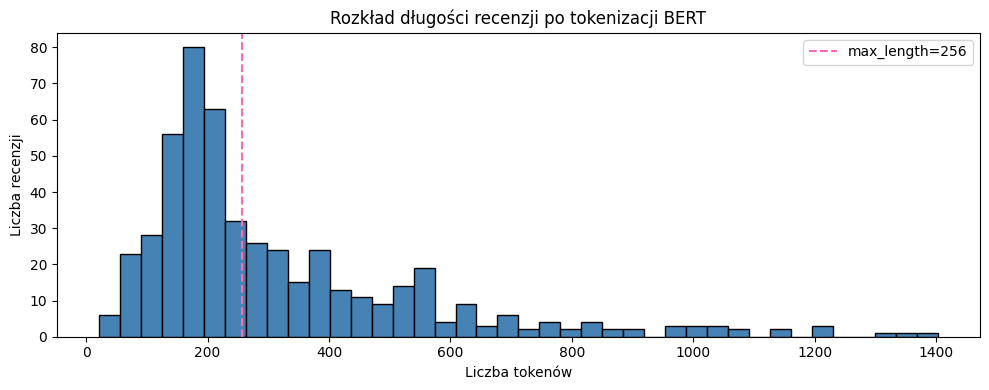

In [21]:
# Analiza długości sekwencji przed tokenizacją — dobór optymalnego max_length
sample_texts = train_df[TEXT_COL].sample(500, random_state=SEED).tolist()
lengths = [len(tokenizer.encode(t, truncation=False)) for t in sample_texts]

print(f'Mediana: {np.median(lengths):.0f} tokenów')
print(f'P75: {np.percentile(lengths, 75):.0f} tokenów')
print(f'P90: {np.percentile(lengths, 90):.0f} tokenów')
print(f'Maksimum: {max(lengths)} tokenów')

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(lengths, bins=40, color='steelblue', edgecolor='black')
# Linia pokazuje gdzie będą przycinane recenzje
ax.axvline(256, color='hotpink', linestyle='--', label='max_length=256')
ax.set_title('Rozkład długości recenzji po tokenizacji BERT')
ax.set_xlabel('Liczba tokenów')
ax.set_ylabel('Liczba recenzji')
ax.legend()
plt.tight_layout()
plt.savefig('bert_token_lengths.png', dpi=150)
plt.show()




In [22]:
# max_length=256 obcina długie recenzje
MAX_LENGTH = 256

def tokenize_fn(examples: dict) -> dict:
    """Tokenizuje teksty i przycina do MAX_LENGTH."""
    return tokenizer(
        examples[TEXT_COL], max_length=MAX_LENGTH,
        truncation=True, padding=False,
    )

# Konwersja DataFrame na HuggingFace Dataset
hf_train = Dataset.from_pandas(train_df[[TEXT_COL, 'labels']])
hf_val = Dataset.from_pandas(val_df[[TEXT_COL, 'labels']])
hf_test = Dataset.from_pandas(test_df[[TEXT_COL, 'labels']])

# Tokenizacja wszystkich zbiorów
tok_train = hf_train.map(tokenize_fn, batched=True, remove_columns=[TEXT_COL])
tok_val = hf_val.map(tokenize_fn, batched=True, remove_columns=[TEXT_COL])
tok_test = hf_test.map(tokenize_fn, batched=True, remove_columns=[TEXT_COL])

print('Tokenizacja zakończona.')
print(f'Kolumny: {tok_train.column_names}')

Map:   0%|          | 0/7000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1500 [00:00<?, ? examples/s]

Map:   0%|          | 0/1500 [00:00<?, ? examples/s]

Tokenizacja zakończona.
Kolumny: ['labels', 'input_ids', 'token_type_ids', 'attention_mask']


In [23]:
# Załadowanie modelu BERT z głową klasyfikacyjną
model_bert = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=2, id2label=ID2LABEL, label2id=LABEL2ID
)

# Liczba parametrów modelu
n_params = sum(p.numel() for p in model_bert.parameters())
print(f'Model: {MODEL_NAME}')
print(f'Parametry: {n_params:,}')
print(f'Liczba klas: 2 (negative / positive)')

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model: bert-base-uncased
Parametry: 109,483,778
Liczba klas: 2 (negative / positive)


In [24]:
# Funkcja metryk wywoływana przez Trainer po każdej epoce ewaluacji
def compute_metrics(eval_pred) -> dict:
    """Oblicza accuracy i F1 weighted na zbiorze walidacyjnym."""
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)  # wybór klasy z najwyższym logitem
    return {
        'accuracy': accuracy_score(labels, preds),
        'f1_weighted': f1_score(labels, preds, average='weighted'),
    }

In [25]:
# Konfiguracja treningu
training_args = TrainingArguments(
    output_dir='./bert-imdb',     # folder na checkpointy

    # Hiperparametry treningu
    learning_rate=2e-5,
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    warmup_steps=100,    # liczba kroków rozgrzewki
    weight_decay=0.01,   # regularyzacja L2

    # Ewaluacja i zapis najlepszego modelu
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1_weighted',

    # Mixed precision przyspiesza trening na GPU
    fp16=torch.cuda.is_available(),

    seed=SEED,
    logging_steps=100,
    report_to='none',
)

In [26]:
# Inicjalizacja Trainera
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

trainer_kwargs = dict(
    model=model_bert, args=training_args,
    train_dataset=tok_train, eval_dataset=tok_val,
    data_collator=data_collator, compute_metrics=compute_metrics,
)

# Detekcja wersji transformers l
if 'processing_class' in inspect.signature(Trainer.__init__).parameters:
    trainer_kwargs['processing_class'] = tokenizer
else:
    trainer_kwargs['tokenizer'] = tokenizer

trainer = Trainer(**trainer_kwargs)
print('Trainer gotowy!')

Trainer gotowy!


In [27]:
# Fine-tuning BERT na zbiorze treningowym
print(f'Rozpoczynam fine-tuning {MODEL_NAME} (3 epoki)...\n')
trainer.train()
print('\nFine-tuning zakończony!')

Rozpoczynam fine-tuning bert-base-uncased (3 epoki)...



Epoch,Training Loss,Validation Loss,Accuracy,F1 Weighted
1,0.307984,0.225456,0.909333,0.909297
2,0.160679,0.289297,0.904667,0.904573
3,0.084416,0.386638,0.910000,0.909986


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


Fine-tuning zakończony!


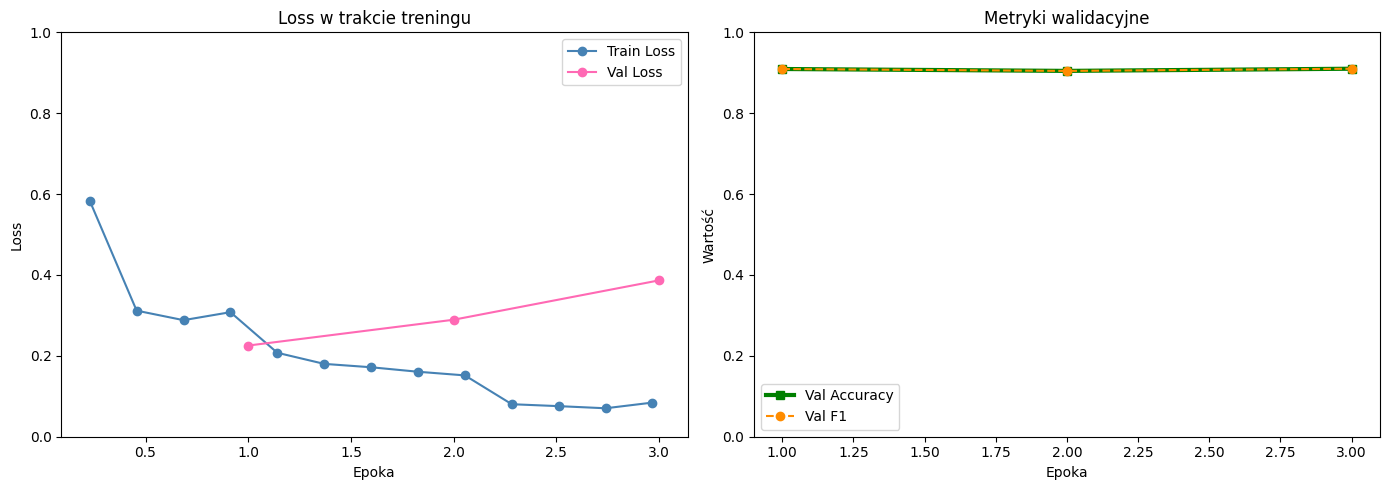

In [35]:
# Wykres loss i metryk walidacyjnych w trakcie treningu
logs = trainer.state.log_history

train_losses = [(l['epoch'], l['loss']) for l in logs if 'loss' in l and 'eval_loss' not in l]
val_metrics = [(l['epoch'], l['eval_loss'], l['eval_accuracy'], l['eval_f1_weighted'])
                for l in logs if 'eval_loss' in l]

if train_losses and val_metrics:
    t_ep, t_loss = zip(*train_losses)
    v_ep, v_loss, v_acc, v_f1 = zip(*val_metrics)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Porównanie train loss i val loss
    axes[0].plot(t_ep, t_loss, label='Train Loss', marker='o', color='steelblue')
    axes[0].plot(v_ep, v_loss, label='Val Loss', marker='o', color='hotpink')
    axes[0].set_title('Loss w trakcie treningu')
    axes[0].set_xlabel('Epoka')
    axes[0].set_ylabel('Loss')
    axes[0].set_ylim(0, 1)
    axes[0].legend()

    # Accuracy i F1 na zbiorze walidacyjnym
    axes[1].plot(v_ep, v_acc, label='Val Accuracy', marker='s', color='green', linewidth=3)
    axes[1].plot(v_ep, v_f1,  label='Val F1', marker='o', color='darkorange', linestyle='--')
    axes[1].set_title('Metryki walidacyjne')
    axes[1].set_xlabel('Epoka')
    axes[1].set_ylabel('Wartość')
    axes[1].set_ylim(0, 1)
    axes[1].legend()

    plt.tight_layout()
    plt.savefig('bert_training_history.png', dpi=150)
    plt.show()

In [29]:
# Ewaluacja BERT na zbiorze testowym
predictions_output = trainer.predict(tok_test)

# Konwersja logitów na etykiety tekstowe
y_pred_ids = np.argmax(predictions_output.predictions, axis=-1)
y_true_ids = predictions_output.label_ids

y_pred_bert = [ID2LABEL[i] for i in y_pred_ids]
y_true_bert = [ID2LABEL[i] for i in y_true_ids]

# Obliczenie metryk
bert_test_acc = accuracy_score(y_true_bert, y_pred_bert)
bert_test_prec = precision_score(y_true_bert, y_pred_bert, average='weighted')
bert_test_rec = recall_score(y_true_bert, y_pred_bert, average='weighted')
bert_test_f1 = f1_score(y_true_bert, y_pred_bert, average='weighted')

print('=== Wyniki BERT na zbiorze testowym ===')
print(f'Accuracy: {bert_test_acc:.4f}')
print(f'Precision: {bert_test_prec:.4f}')
print(f'Recall: {bert_test_rec:.4f}')
print(f'F1: {bert_test_f1:.4f}')
print(f'\nRaport klasyfikacji:')
print(classification_report(y_true_bert, y_pred_bert))

=== Wyniki BERT na zbiorze testowym ===
Accuracy: 0.9133
Precision: 0.9141
Recall: 0.9133
F1: 0.9133

Raport klasyfikacji:
              precision    recall  f1-score   support

    negative       0.93      0.89      0.91       750
    positive       0.90      0.93      0.92       750

    accuracy                           0.91      1500
   macro avg       0.91      0.91      0.91      1500
weighted avg       0.91      0.91      0.91      1500



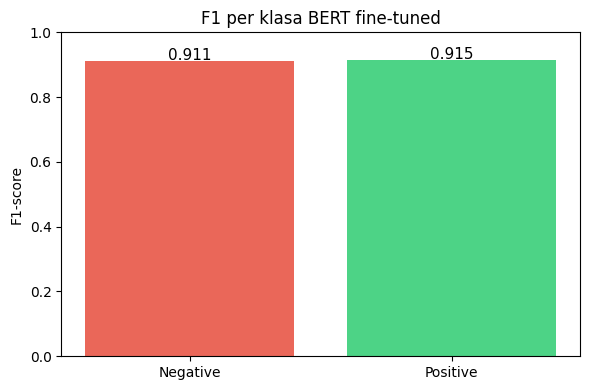

In [40]:
# F1 per klasa BERT fine-tuned
report_bert = classification_report(
    y_true_bert, y_pred_bert,
    target_names=['Negative', 'Positive'],
    output_dict=True
)

f1_bert = [report_bert[c]['f1-score'] for c in classes]

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(classes, f1_bert, color=['#e74c3c', '#2ecc71'], alpha=0.85)
for i, v in enumerate(f1_bert):
    ax.text(i, v + 0.003, f'{v:.3f}', ha='center', fontsize=11)
ax.set_ylim(0, 1)
ax.set_ylabel('F1-score')
ax.set_title('F1 per klasa BERT fine-tuned')
plt.tight_layout()
plt.savefig('f1_per_class_bert.png', dpi=150)
plt.show()

In [31]:
# Zapis wyników BERT do JSON
bert_results = {
    'model': 'bert-base-uncased (fine-tuned)',
    'params': {
        'learning_rate': 2e-5,
        'num_train_epochs': 3,
        'per_device_train_batch': 16,
        'max_length': MAX_LENGTH,
        'warmup_steps': 100,
        'weight_decay': 0.01,
    },
    'accuracy': round(bert_test_acc, 4),
    'precision': round(bert_test_prec, 4),
    'recall': round(bert_test_rec, 4),
    'f1': round(bert_test_f1, 4),
}

with open('results_bert.json', 'w', encoding='utf-8') as f:
    json.dump(bert_results, f, ensure_ascii=False, indent=2)

print('Zapisano: results_bert.json')
print(bert_results)

Zapisano: results_bert.json
{'model': 'bert-base-uncased (fine-tuned)', 'params': {'learning_rate': 2e-05, 'num_train_epochs': 3, 'per_device_train_batch': 16, 'max_length': 256, 'warmup_steps': 100, 'weight_decay': 0.01}, 'accuracy': 0.9133, 'precision': 0.9141, 'recall': 0.9133, 'f1': 0.9133}


In [32]:
# Zapis predykcji obu modeli do CSV
results_df = test_df.copy()
results_df['pred_classic'] = y_test_pred_classic
results_df['pred_transformer'] = y_pred_bert
results_df.to_csv('test_predictions.csv', index=False)

# Zapis modelu BERT i tokenizatora
trainer.save_model('./bert-imdb-final')
tokenizer.save_pretrained('./bert-imdb-final')

print('Zapisano: test_predictions.csv')
print('Model BERT: ./bert-imdb-final')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Zapisano: test_predictions.csv
Model BERT: ./bert-imdb-final


## Podsumowanie

W tym notebooku zaimplementowałam dwa podejścia do klasyfikacji sentymentu recenzji IMDB.

**Podejście klasyczne:** Porównałam trzy klasyfikatory na reprezentacji TF-IDF. SVM osiągnął najlepszy wynik z accuracy 0.863, nieznacznie wyprzedzając Logistic Regression i Naive Bayes. Następnie zastosowałam GridSearchCV do optymalizacji hiperparametrów. Wyniki w `results_classic.json`.

**Podejście transformerowe:** Fine-tuning modelu bert-base-uncased przez 3 epoki z Trainer API i max_length=256. Najlepszy model pochodzi z epoki 2 z accuracy 0.911 na walidacji i 0.911 na teście. Wyniki w `results_bert.json`.

**Zapisane pliki:**
- `results_classic.json` — metryki i parametry modelu klasycznego
- `results_bert.json` — metryki i parametry BERT
- `test_predictions.csv` — predykcje obu modeli na zbiorze testowym
- `bert-imdb-final/` — zapisany model BERT z tokenizatorem

**Następny:** `3_ewaluacja_i_analiza.ipynb`